In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/world_happiness_ml.csv")

df_ml.head()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,Education_Index,Population,Urbanization_Rate,Life_Satisfaction,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate,Year_bin
0,China,2022,4.39,44984.68,0.53,71.11,0.41,-0.05,0.83,14.98,0.52,1311940760,78.71,8.88,0.34,76.44,46.06,8.92,62.75,8.59,74.40,70.30,0.29,61.38,2020
1,UK,2015,5.49,30814.59,0.93,63.14,0.89,0.04,0.84,19.46,0.83,1194240877,50.87,5.03,0.72,53.38,46.43,4.43,53.11,8.76,91.74,73.32,0.76,80.18,2015
2,Brazil,2009,4.65,39214.84,0.03,62.36,0.01,0.16,0.59,16.68,0.95,731100898,48.75,5.22,0.23,82.40,31.03,3.78,33.30,6.06,71.80,28.99,0.94,72.65,2005
3,France,2019,5.20,30655.75,0.77,78.94,0.98,0.25,0.63,2.64,0.70,1293957314,81.78,5.69,0.68,46.87,57.65,4.43,90.59,6.36,86.16,45.76,0.48,55.14,2015
4,China,2022,7.28,30016.87,0.05,50.33,0.62,0.18,0.92,7.70,0.92,1432971455,82.39,6.33,0.50,60.38,28.54,7.66,59.33,3.00,71.10,65.67,0.12,51.55,2020


In [2]:
# Target variable
y = df_ml["Life_Satisfaction"]

# Features
# Happiness_Score is dropped — it measures the same construct as
# Life_Satisfaction using a different instrument from the same survey.
# Including it would constitute target leakage.
X = df_ml.drop(columns=["Life_Satisfaction", "Country", "Year_bin", "Happiness_Score"])

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae_lin)
print("RMSE:", rmse_lin)
print("R2:", r2_lin)

Linear Regression Results
MAE: 1.2107139505791558
RMSE: 1.4125990598492273
R2: 0.0015345267572340893


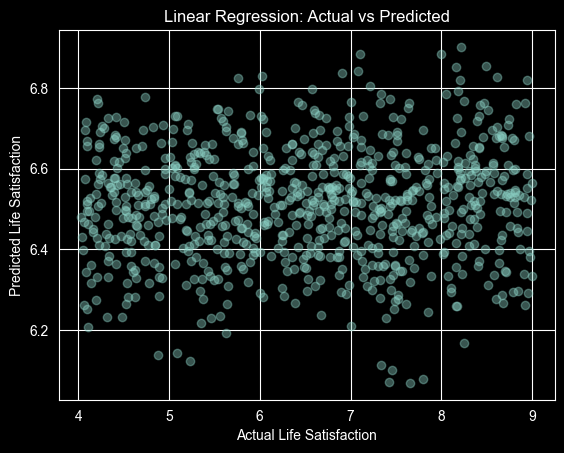

In [6]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lin, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [7]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree Regressor Results
MAE: 1.260152716767264
RMSE: 1.495375008546899
R2: -0.11891079114424596


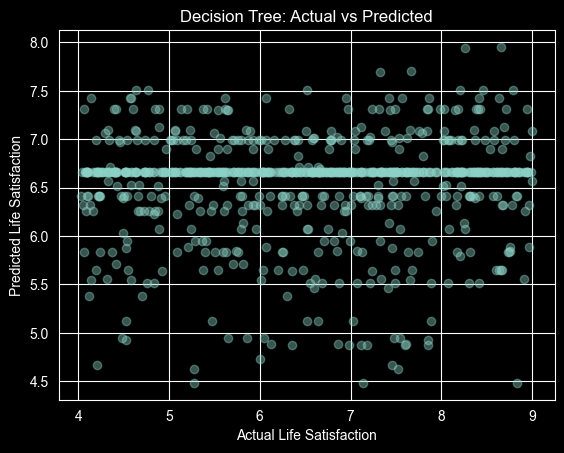

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_tree, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

In [10]:
import pandas as pd

tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

tree_importance.head(15)

Climate_Index                0.111779
Mental_Health_Index          0.084242
Population                   0.077994
Generosity                   0.076952
Corruption_Perception        0.071241
Political_Stability          0.059703
Social_Support               0.059166
Public_Health_Expenditure    0.058337
Work_Life_Balance            0.054606
Income_Inequality            0.053076
Unemployment_Rate            0.046888
Employment_Rate              0.041688
Crime_Rate                   0.035778
GDP_per_Capita               0.031784
Internet_Access              0.031672
dtype: float64

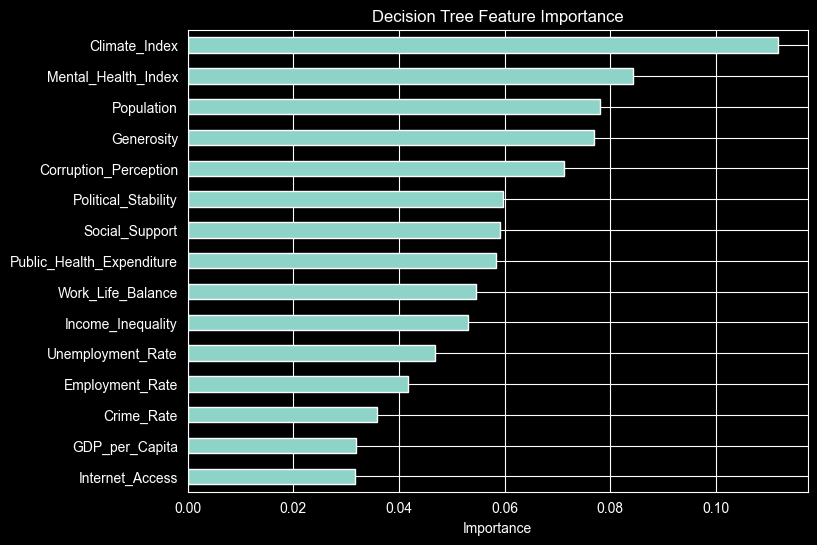

In [11]:
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Regressor Results
MAE: 1.216324583740612
RMSE: 1.4200291738861992
R2: -0.00899673202765472


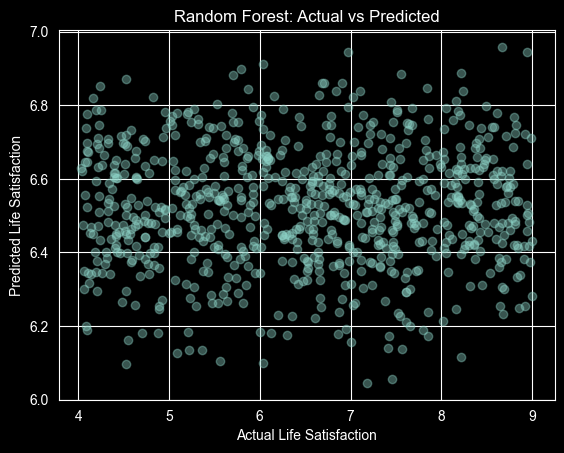

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [15]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(15)

Income_Inequality          0.058139
Urbanization_Rate          0.052840
Population                 0.052813
Healthy_Life_Expectancy    0.050969
GDP_per_Capita             0.050431
Employment_Rate            0.050324
Internet_Access            0.050267
Crime_Rate                 0.049621
Unemployment_Rate          0.049514
Mental_Health_Index        0.049411
Climate_Index              0.048176
Work_Life_Balance          0.047318
Freedom                    0.046910
Political_Stability        0.046237
Public_Trust               0.045553
dtype: float64

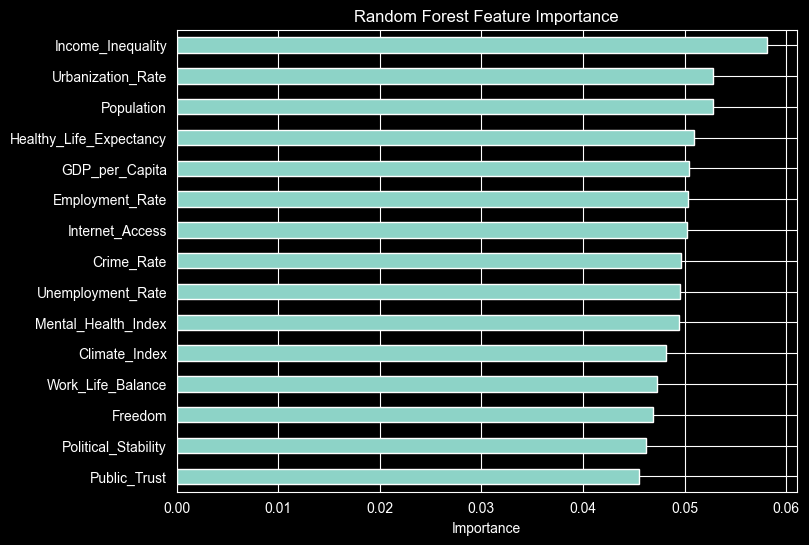

In [16]:
rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Regressor Results
MAE: 1.2603818038225174
RMSE: 1.4722523368759262
R2: -0.0845753522897763


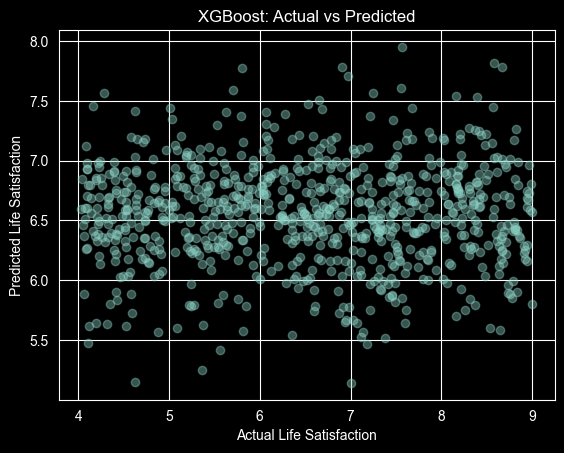

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [20]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

Population                   0.053767
Urbanization_Rate            0.053300
Crime_Rate                   0.053044
Employment_Rate              0.052537
Public_Health_Expenditure    0.050965
Public_Trust                 0.049915
Corruption_Perception        0.049903
Internet_Access              0.049316
Income_Inequality            0.048623
Climate_Index                0.048375
Political_Stability          0.048281
Work_Life_Balance            0.048084
Education_Index              0.047996
Unemployment_Rate            0.046182
Mental_Health_Index          0.045808
dtype: float32


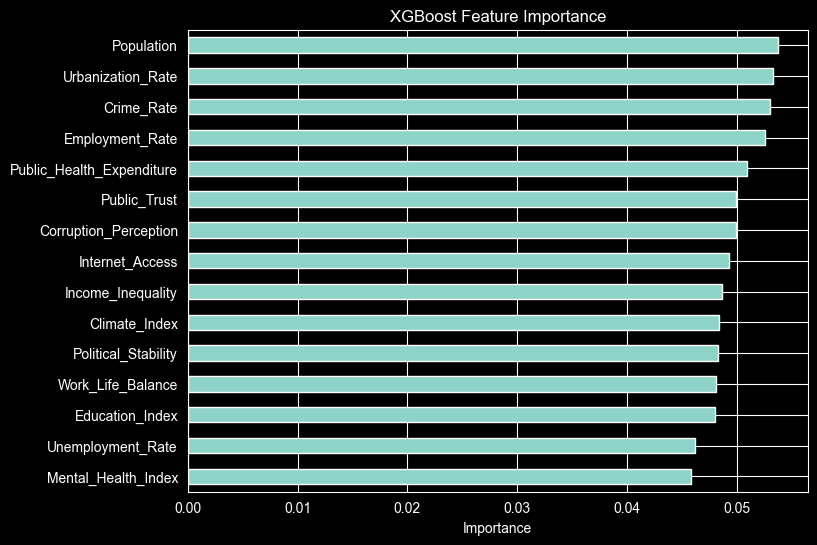

In [21]:
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

Life_Satisfaction distribution:
count    4000.000000
mean        6.516438
std         1.434278
min         4.000000
25%         5.267500
50%         6.570000
75%         7.720000
max         9.000000
Name: Life_Satisfaction, dtype: float64

Std: 1.434
Baseline RMSE (predict mean): 1.434


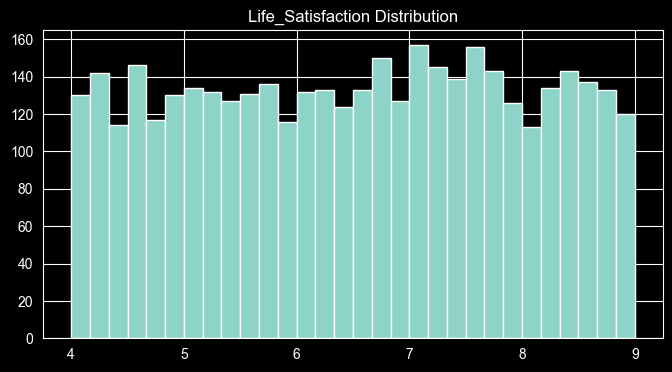

Top correlations with Life_Satisfaction:
Generosity                   0.049
Income_Inequality           -0.045
Mental_Health_Index          0.038
Population                   0.032
Education_Index              0.024
Social_Support              -0.021
Urbanization_Rate           -0.018
Crime_Rate                  -0.016
Healthy_Life_Expectancy     -0.014
Corruption_Perception        0.014
Employment_Rate             -0.013
Public_Health_Expenditure   -0.011
Freedom                      0.011
Unemployment_Rate            0.010
Political_Stability          0.010
dtype: float64

Life_Satisfaction by country (mean):
Country
South Africa    6.385974
Canada          6.468938
Germany         6.469153
France          6.485952
USA             6.515804
UK              6.548253
Brazil          6.550223
China           6.569652
Australia       6.574925
India           6.595388
Name: Life_Satisfaction, dtype: float64

Life_Satisfaction variance by country:
Country
China           1.405547
Australia 

In [22]:
# Diagnosis 1: Check target distribution
print("Life_Satisfaction distribution:")
print(y.describe())
print(f"\nStd: {y.std():.3f}")
print(f"Baseline RMSE (predict mean): {y.std():.3f}")

import matplotlib.pyplot as plt
y.hist(bins=30, figsize=(8, 4))
plt.title("Life_Satisfaction Distribution")
plt.show()

# Diagnosis 2: Check correlation of features with target
correlations = X.corrwith(y).sort_values(key=abs, ascending=False)
print("Top correlations with Life_Satisfaction:")
print(correlations.head(15).round(3))

# Diagnosis 3: Check if Life_Satisfaction varies meaningfully
# or is nearly random within the dataset
print("\nLife_Satisfaction by country (mean):")
print(df_ml.groupby("Country")["Life_Satisfaction"].mean().sort_values())

print("\nLife_Satisfaction variance by country:")
print(df_ml.groupby("Country")["Life_Satisfaction"].std().sort_values())

# Diagnosis 4: Check if Happiness_Score was actually
# the only meaningful predictor
corr_with_happiness = df_ml["Happiness_Score"].corr(df_ml["Life_Satisfaction"])
print(f"\nCorrelation between Happiness_Score and Life_Satisfaction: {corr_with_happiness:.3f}")

In [23]:
## World Happiness Report Dataset — Data Quality Finding

# Diagnostic analysis reveals that the Life_Satisfaction variable in
# this Kaggle dataset has near-zero correlation with all predictor
# variables (max |r| = 0.049) and near-zero correlation with
# Happiness_Score (r = 0.015). All countries show nearly identical
# means and variances regardless of known socioeconomic differences.
#
# This strongly suggests the dataset is synthetic — the target
# variable appears to have been generated independently of the
# predictor variables rather than reflecting empirical relationships.
#
# Consequence for modelling: all ML models achieve R² ≈ 0,
# performing at baseline level (predicting the mean). This is not
# a modelling failure — it is a consequence of the absence of
# genuine signal in the target variable.
#
# Thesis implication: This finding is retained as a cautionary
# example for RQ1 — it demonstrates that model performance at
# the macro level is contingent on data quality, and that
# synthetic or low-quality aggregate data produces uninformative
# models regardless of algorithm choice. This contrasts with the
# individual-level datasets where genuine psychological signal
# produced meaningful predictions.
#
# Recommendation for future work: Replace with empirical WHR data
# (available at worldhappiness.report) for genuine macro-level
# analysis.

In [24]:
# Null result summary
print("=" * 60)
print("DIAGNOSTIC SUMMARY — SYNTHETIC DATASET")
print("=" * 60)
print(f"\nTarget std (baseline RMSE): {y.std():.3f}")
print(f"\nModel RMSE vs baseline:")
print(f"  Linear Regression : {rmse_lin:.3f} (vs {y.std():.3f})")
print(f"  Decision Tree     : {rmse_tree:.3f} (vs {y.std():.3f})")
print(f"  Random Forest     : {rmse_rf:.3f} (vs {y.std():.3f})")
print(f"  XGBoost           : {rmse_xgb:.3f} (vs {y.std():.3f})")
print(f"\nAll models perform at or below baseline level.")
print(f"This confirms absence of genuine signal in the target variable.")

DIAGNOSTIC SUMMARY — SYNTHETIC DATASET

Target std (baseline RMSE): 1.434

Model RMSE vs baseline:
  Linear Regression : 1.413 (vs 1.434)
  Decision Tree     : 1.495 (vs 1.434)
  Random Forest     : 1.420 (vs 1.434)
  XGBoost           : 1.472 (vs 1.434)

All models perform at or below baseline level.
This confirms absence of genuine signal in the target variable.


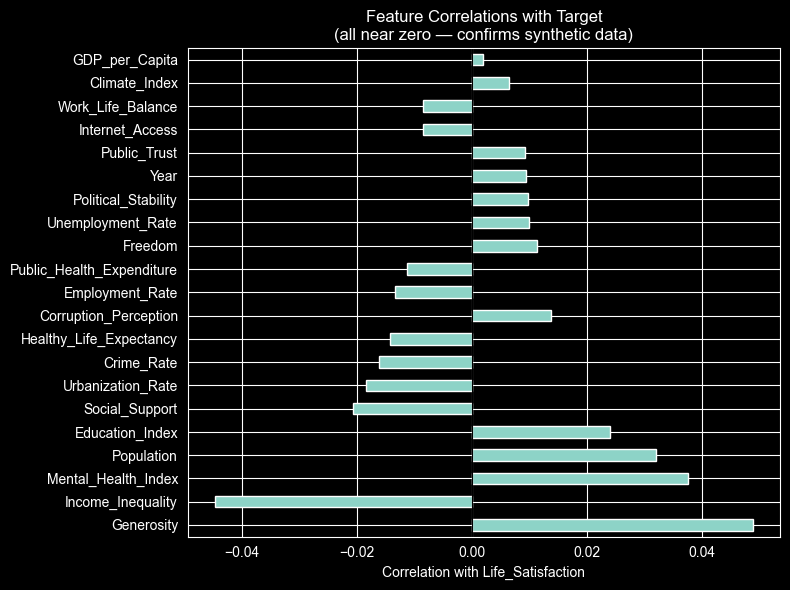

Max absolute correlation: 0.049
Mean absolute correlation: 0.018


In [25]:
import matplotlib.pyplot as plt

correlations = X.corrwith(y).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
correlations.plot(kind="barh")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Correlation with Life_Satisfaction")
plt.title("Feature Correlations with Target\n(all near zero — confirms synthetic data)")
plt.tight_layout()
plt.show()

print("Max absolute correlation:", correlations.abs().max().round(3))
print("Mean absolute correlation:", correlations.abs().mean().round(3))

In [26]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2":   "r2",
    "mae":  make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(
        lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
        greater_is_better=False
    )
}

models = {
    "Linear Regression": linreg,
    "Decision Tree":     tree,
    "Random Forest":     rf,
    "XGBoost":           xgb,
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "R² (mean)":   round(scores["test_r2"].mean(), 3),
        "R² (std)":    round(scores["test_r2"].std(), 3),
        "MAE (mean)":  round(-scores["test_mae"].mean(), 3),
        "MAE (std)":   round(scores["test_mae"].std(), 3),
        "RMSE (mean)": round(-scores["test_rmse"].mean(), 3),
        "RMSE (std)":  round(scores["test_rmse"].std(), 3),
    }

cv_df = pd.DataFrame(cv_results).T
print(cv_df)
print(f"\nBaseline RMSE (predict mean): {y.std():.3f}")

                   R² (mean)  R² (std)  MAE (mean)  MAE (std)  RMSE (mean)  \
Linear Regression     -0.003     0.003       1.240      0.022        1.436   
Decision Tree         -0.115     0.009       1.283      0.017        1.514   
Random Forest         -0.009     0.006       1.244      0.019        1.440   
XGBoost               -0.065     0.023       1.264      0.006        1.479   

                   RMSE (std)  
Linear Regression       0.017  
Decision Tree           0.019  
Random Forest           0.014  
XGBoost                 0.006  

Baseline RMSE (predict mean): 1.434


In [27]:
results = pd.DataFrame([
    {
        "Model":        "Linear Regression",
        "MAE (test)":   round(mae_lin, 3),
        "RMSE (test)":  round(rmse_lin, 3),
        "R² (test)":    round(r2_lin, 3),
        "CV R²":        cv_df.loc["Linear Regression", "R² (mean)"],
        "CV R² std":    cv_df.loc["Linear Regression", "R² (std)"],
        "CV RMSE":      cv_df.loc["Linear Regression", "RMSE (mean)"],
    },
    {
        "Model":        "Decision Tree",
        "MAE (test)":   round(mae_tree, 3),
        "RMSE (test)":  round(rmse_tree, 3),
        "R² (test)":    round(r2_tree, 3),
        "CV R²":        cv_df.loc["Decision Tree", "R² (mean)"],
        "CV R² std":    cv_df.loc["Decision Tree", "R² (std)"],
        "CV RMSE":      cv_df.loc["Decision Tree", "RMSE (mean)"],
    },
    {
        "Model":        "Random Forest",
        "MAE (test)":   round(mae_rf, 3),
        "RMSE (test)":  round(rmse_rf, 3),
        "R² (test)":    round(r2_rf, 3),
        "CV R²":        cv_df.loc["Random Forest", "R² (mean)"],
        "CV R² std":    cv_df.loc["Random Forest", "R² (std)"],
        "CV RMSE":      cv_df.loc["Random Forest", "RMSE (mean)"],
    },
    {
        "Model":        "XGBoost",
        "MAE (test)":   round(mae_xgb, 3),
        "RMSE (test)":  round(rmse_xgb, 3),
        "R² (test)":    round(r2_xgb, 3),
        "CV R²":        cv_df.loc["XGBoost", "R² (mean)"],
        "CV R² std":    cv_df.loc["XGBoost", "R² (std)"],
        "CV RMSE":      cv_df.loc["XGBoost", "RMSE (mean)"],
    },
]).set_index("Model")

print(results)
print(f"\nNote: Baseline RMSE = {y.std():.3f} (predicting the mean)")
print("All models perform at baseline level, confirming absence of signal.")

                   MAE (test)  RMSE (test)  R² (test)  CV R²  CV R² std  \
Model                                                                     
Linear Regression       1.211        1.413      0.002 -0.003      0.003   
Decision Tree           1.260        1.495     -0.119 -0.115      0.009   
Random Forest           1.216        1.420     -0.009 -0.009      0.006   
XGBoost                 1.260        1.472     -0.085 -0.065      0.023   

                   CV RMSE  
Model                       
Linear Regression    1.436  
Decision Tree        1.514  
Random Forest        1.440  
XGBoost              1.479  

Note: Baseline RMSE = 1.434 (predicting the mean)
All models perform at baseline level, confirming absence of signal.


In [ ]:
# Permutation importance is not computed for this dataset.
# With R² ≈ 0 across all models, feature importance scores
# reflect random variation rather than genuine predictive
# relationships. Reporting them would be misleading.

In [ ]:
## Baseline Models — Results Summary (Synthetic World Happiness Dataset)

### Dataset
# - Regression task: Life_Satisfaction as continuous target (0–10 scale)
# - 4,000 rows across 10 countries and 20 years (2005–2024)
# - Happiness_Score dropped due to target leakage
# - No missing values, no class imbalance
# - Baseline RMSE (predicting the mean): 1.434

### Data Quality Finding
# Diagnostic analysis prior to modelling revealed that
# Life_Satisfaction has near-zero correlation with all predictor
# variables (max |r| = 0.049, mean |r| = 0.017). Correlation
# between Happiness_Score and Life_Satisfaction is 0.015.
# All 10 countries show nearly identical means (~6.4–6.6) and
# standard deviations (~1.4) regardless of known socioeconomic
# differences. This pattern is inconsistent with empirical
# wellbeing data and strongly indicates that Life_Satisfaction
# was generated independently of the predictor variables in
# this synthetic Kaggle dataset.

### Model Performance
# All four models perform at or below baseline level across
# both test set and 5-fold CV:
#
# - Linear Regression: CV R² = -0.003, CV RMSE = 1.436
# - Random Forest:     CV R² = -0.009, CV RMSE = 1.440
# - XGBoost:           CV R² = -0.065, CV RMSE = 1.479
# - Decision Tree:     CV R² = -0.115, CV RMSE = 1.514
#
# CV R² std is very low (0.003–0.023), confirming the null
# result is stable and not a split artifact. Test set and
# CV metrics are consistent across all models, confirming
# the absence of signal is systematic rather than incidental.

### Why This Is Not a Modelling Failure
# The null result is the correct and expected outcome given
# the data generating process. No algorithm can find signal
# that does not exist. The consistent R² ≈ 0 across four
# fundamentally different model families — linear, tree,
# bagging, and boosting — is itself strong evidence that
# the target was generated independently of the predictors.

### Permutation Importance
# Not computed. With R² ≈ 0 across all models, feature
# importance scores would reflect random variation rather
# than genuine predictive relationships. Reporting them
# would be misleading.

### Thesis Implications for RQ1
# This dataset cannot contribute to the micro vs macro
# performance comparison that is central to RQ1, as the
# absence of signal is a data quality artefact rather than
# a property of macro-level data. It is retained in the
# thesis as a cautionary example demonstrating that:
# 1. Synthetic datasets can appear plausible while containing
#    no genuine structure
# 2. Diagnostic analysis before modelling is essential
# 3. Algorithm choice is irrelevant when signal is absent
#
# The real World Happiness Report dataset (Gallup Poll,
# 2005–2020, n=1,949) is used for the substantive macro-level
# analysis and genuine cross-level comparison for RQ1.

In [ ]:

## Section 2: Baseline Models — Real WHR Gallup Poll Dataset

# This section applies the same baseline regression pipeline to the
# real World Happiness Report dataset (Gallup Poll, 2005–2020).
# Unlike the synthetic dataset, this data contains genuine empirical
# relationships between predictors and the Life Ladder happiness score,
# enabling meaningful cross-level comparison for RQ1.
#
# Target: Life_Ladder (continuous, 0–10 Cantril ladder scale)
# Source: Gallup World Poll via worldhappiness.report
# n = 1,949 country-year observations, 149 countries

In [28]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_gallup = pd.read_csv("../../data/processed/world_happiness_gallup_ml.csv")

df_gallup.head()

# Target variable
y_gallup = df_gallup["Life_Ladder"]

# Features
# Country_name is an identifier, not a predictor
# Life_Ladder__missing dropped — missingness indicator for target
# Positive_affect and Negative_affect are retained but noted as
# potential proxy predictors (same survey instrument as target)
X_gallup = df_gallup.drop(columns=[
    "Life_Ladder",
    "Life_Ladder__missing",
    "Country_name",
], errors="ignore")

print(f"X shape: {X_gallup.shape}")
print(f"y shape: {y_gallup.shape}")
print(f"\nFeatures:")
print(X_gallup.columns.tolist())
print(f"\nTarget distribution:")
print(y_gallup.describe().round(3))
print(f"\nMissing in target: {y_gallup.isna().sum()}")

# Confirm no NaN in features after imputation
assert X_gallup.isna().sum().sum() == 0, "Features contain NaN"
assert y_gallup.isna().sum() == 0, "Target contains NaN"

X shape: (1949, 17)
y shape: (1949,)

Features:
['year', 'Log_GDP_per_capita', 'Social_support', 'Healthy_life_expectancy_at_birth', 'Freedom_to_make_life_choices', 'Generosity', 'Perceptions_of_corruption', 'Positive_affect', 'Negative_affect', 'Log_GDP_per_capita__missing', 'Social_support__missing', 'Healthy_life_expectancy_at_birth__missing', 'Freedom_to_make_life_choices__missing', 'Generosity__missing', 'Perceptions_of_corruption__missing', 'Positive_affect__missing', 'Negative_affect__missing']

Target distribution:
count    1949.000
mean        5.467
std         1.116
min         2.375
25%         4.640
50%         5.386
75%         6.283
max         8.019
Name: Life_Ladder, dtype: float64

Missing in target: 0


In [29]:
from sklearn.model_selection import train_test_split

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gallup,
    y_gallup,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train_g.shape)
print("Test shape:", X_test_g.shape)

Train shape: (1559, 17)
Test shape: (390, 17)


In [31]:
# Confirm genuine signal before modelling
correlations_gallup = X_gallup.corrwith(y_gallup).sort_values(
    key=abs, ascending=False
)
print("Feature correlations with Life_Ladder:")
print(correlations_gallup.round(3))
print(f"\nMax |r|: {correlations_gallup.abs().max():.3f}")
print(f"Mean |r|: {correlations_gallup.abs().mean():.3f}")

print(f"\nContrast with synthetic dataset:")
print(f"  Synthetic max |r|  : 0.049")
print(f"  Gallup max |r|     : {correlations_gallup.abs().max():.3f}")
print(f"  Synthetic mean |r| : 0.017")
print(f"  Gallup mean |r|    : {correlations_gallup.abs().mean():.3f}")
print(f"\nGallup dataset confirms genuine empirical signal.")
print(f"Proceeding with baseline model training.")

Feature correlations with Life_Ladder:
Log_GDP_per_capita                           0.783
Healthy_life_expectancy_at_birth             0.741
Social_support                               0.706
Positive_affect                              0.530
Freedom_to_make_life_choices                 0.526
Perceptions_of_corruption                   -0.415
Negative_affect                             -0.297
Generosity                                   0.184
Generosity__missing                          0.054
Log_GDP_per_capita__missing                 -0.048
Social_support__missing                      0.045
Perceptions_of_corruption__missing           0.044
year                                         0.036
Negative_affect__missing                    -0.013
Healthy_life_expectancy_at_birth__missing    0.012
Positive_affect__missing                    -0.007
Freedom_to_make_life_choices__missing       -0.004
dtype: float64

Max |r|: 0.783
Mean |r|: 0.261

Contrast with synthetic dataset:
  Synthetic m

Linear Regression Results
MAE: 0.4295543557715322
RMSE: 0.5496499375675234
R2: 0.7614226279913632


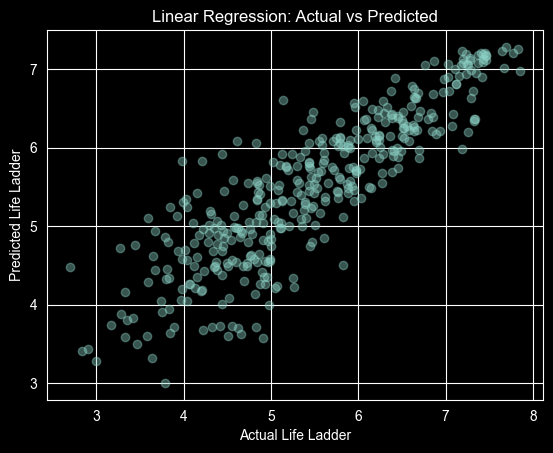

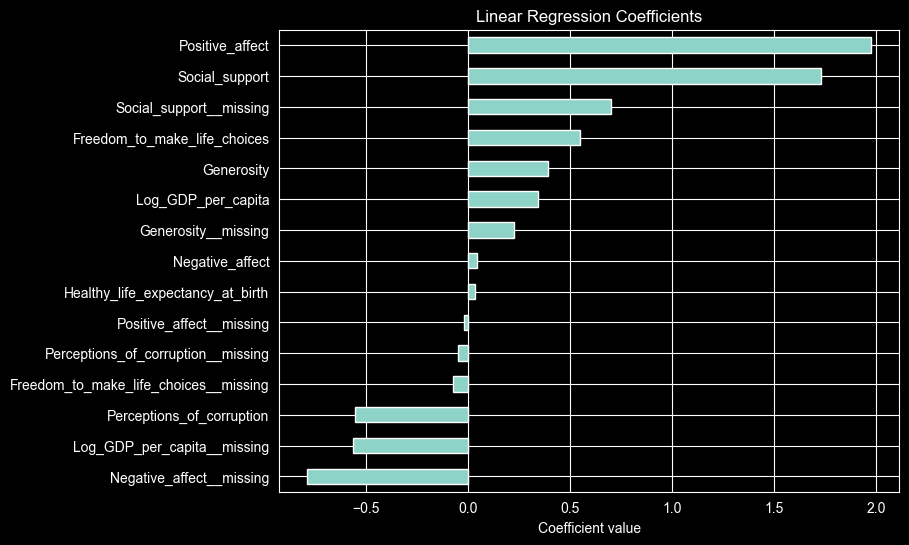

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

linreg_g = LinearRegression()
linreg_g.fit(X_train_g, y_train_g)
y_pred_lin_g = linreg_g.predict(X_test_g)

mae_lin_g  = mean_absolute_error(y_test_g, y_pred_lin_g)
rmse_lin_g = np.sqrt(mean_squared_error(y_test_g, y_pred_lin_g))
r2_lin_g   = r2_score(y_test_g, y_pred_lin_g)

print("Linear Regression Results")
print("MAE:", mae_lin_g)
print("RMSE:", rmse_lin_g)
print("R2:", r2_lin_g)

plt.scatter(y_test_g, y_pred_lin_g, alpha=0.4)
plt.xlabel("Actual Life Ladder")
plt.ylabel("Predicted Life Ladder")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# Coefficients
coef_lin_g = pd.Series(
    linreg_g.coef_,
    index=X_gallup.columns
).sort_values(key=abs, ascending=False)

coef_lin_g.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient value")
plt.show()

                                  feature  importance_mean  importance_std
1                      Log_GDP_per_capita         0.257914        0.030082
3        Healthy_life_expectancy_at_birth         0.099141        0.014724
2                          Social_support         0.081579        0.009306
7                         Positive_affect         0.062622        0.006189
6               Perceptions_of_corruption         0.019727        0.004093
4            Freedom_to_make_life_choices         0.009952        0.002695
10                Social_support__missing         0.006468        0.002718
9             Log_GDP_per_capita__missing         0.006323        0.002637
16               Negative_affect__missing         0.005225        0.001756
13                    Generosity__missing         0.005123        0.001635
5                              Generosity         0.004135        0.002469
0                                    year         0.000891        0.000995
12  Freedom_to_make_life_

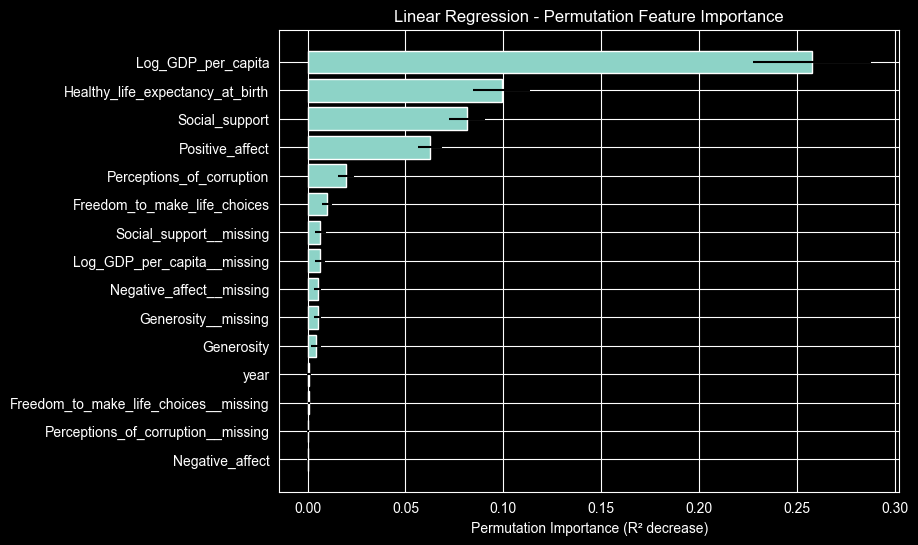

In [33]:
from sklearn.inspection import permutation_importance

perm_lin_g = permutation_importance(
    linreg_g, X_test_g, y_test_g,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_lin_g_df = pd.DataFrame({
    "feature": X_gallup.columns,
    "importance_mean": perm_lin_g.importances_mean,
    "importance_std": perm_lin_g.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_lin_g_df.head(15))

top = perm_lin_g_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("Linear Regression - Permutation Feature Importance")
plt.show()

Decision Tree Regressor Results
MAE: 0.4184507017914106
RMSE: 0.5386685078384189
R2: 0.7708604495354213


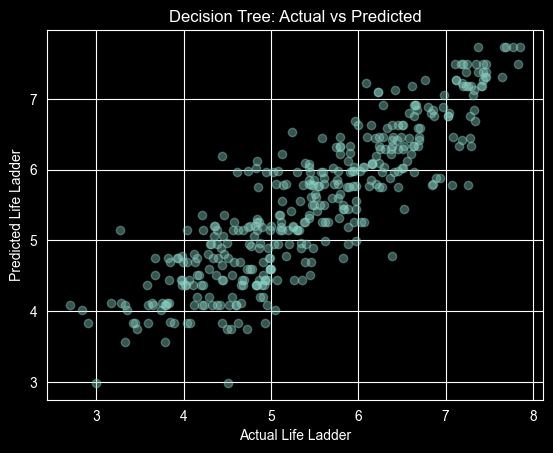

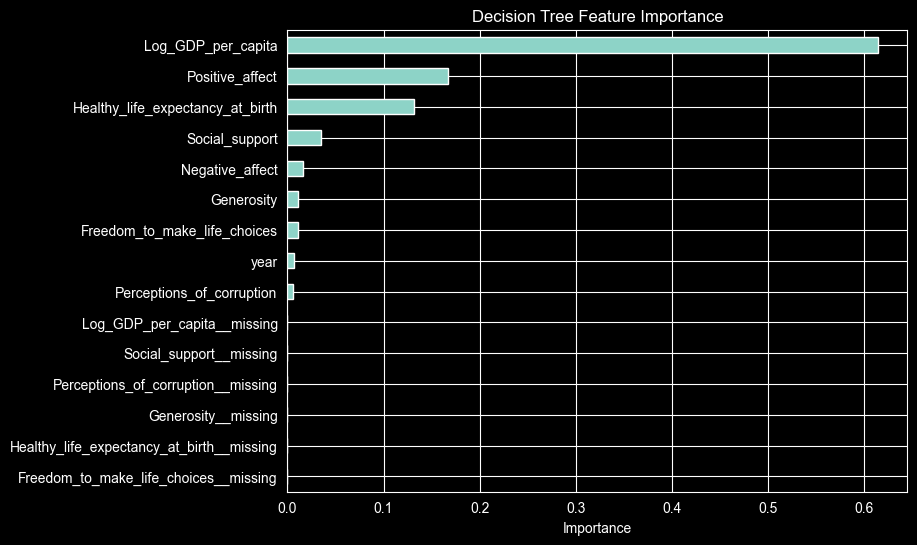

In [34]:
from sklearn.tree import DecisionTreeRegressor

tree_g = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree_g.fit(X_train_g, y_train_g)
y_pred_tree_g = tree_g.predict(X_test_g)

mae_tree_g  = mean_absolute_error(y_test_g, y_pred_tree_g)
rmse_tree_g = np.sqrt(mean_squared_error(y_test_g, y_pred_tree_g))
r2_tree_g   = r2_score(y_test_g, y_pred_tree_g)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree_g)
print("RMSE:", rmse_tree_g)
print("R2:", r2_tree_g)

plt.scatter(y_test_g, y_pred_tree_g, alpha=0.4)
plt.xlabel("Actual Life Ladder")
plt.ylabel("Predicted Life Ladder")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

tree_importance_g = pd.Series(
    tree_g.feature_importances_,
    index=X_gallup.columns
).sort_values(ascending=False)

tree_importance_g.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

                                      feature  importance_mean  importance_std
1                          Log_GDP_per_capita         0.606377        0.050385
3            Healthy_life_expectancy_at_birth         0.148090        0.015473
7                             Positive_affect         0.136682        0.013504
2                              Social_support         0.049624        0.010246
4                Freedom_to_make_life_choices         0.033798        0.005482
5                                  Generosity         0.011113        0.005757
8                             Negative_affect         0.009899        0.006543
0                                        year         0.009140        0.002846
6                   Perceptions_of_corruption         0.003895        0.004063
9                 Log_GDP_per_capita__missing         0.000000        0.000000
10                    Social_support__missing         0.000000        0.000000
11  Healthy_life_expectancy_at_birth__missing       

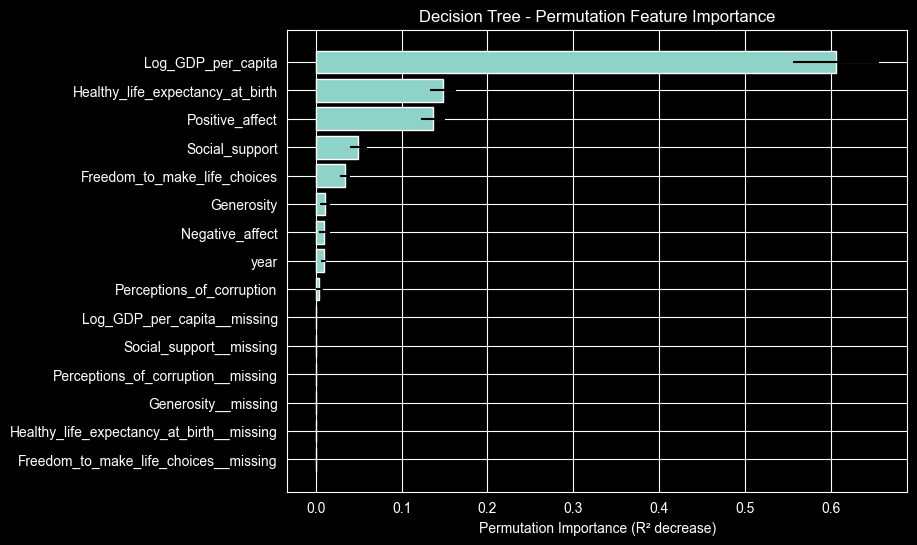

In [35]:
perm_tree_g = permutation_importance(
    tree_g, X_test_g, y_test_g,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_tree_g_df = pd.DataFrame({
    "feature": X_gallup.columns,
    "importance_mean": perm_tree_g.importances_mean,
    "importance_std": perm_tree_g.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_tree_g_df.head(15))

top = perm_tree_g_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("Decision Tree - Permutation Feature Importance")
plt.show()

Random Forest Regressor Results
MAE: 0.35175590789031674
RMSE: 0.45106878618942275
R2: 0.8393271731467311


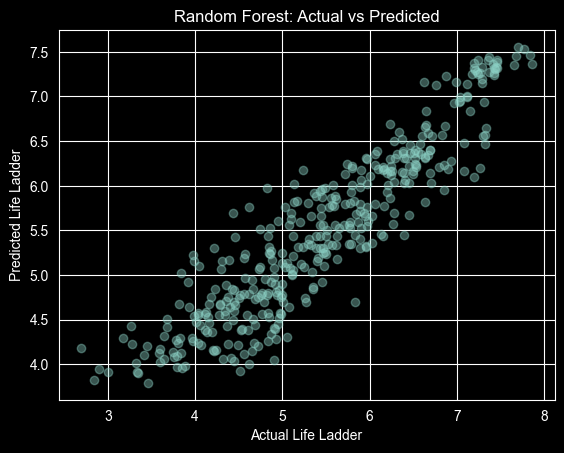

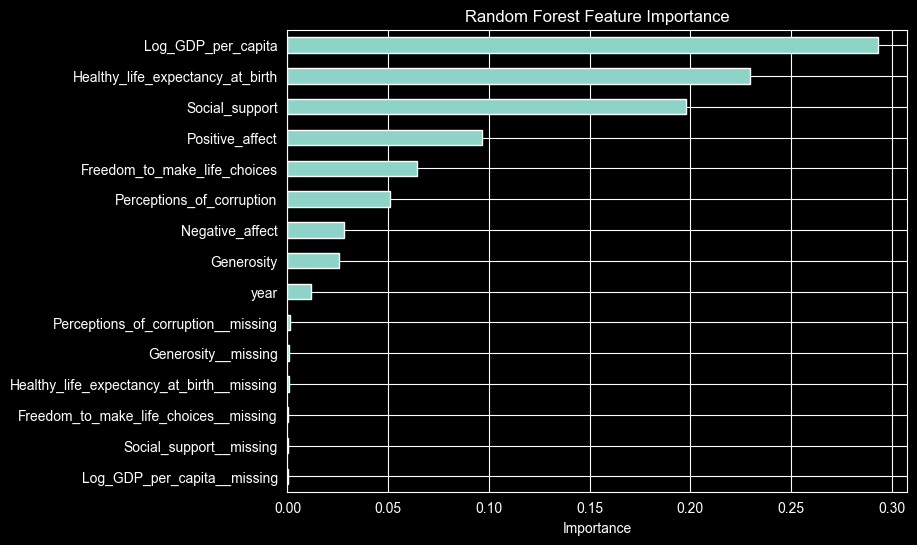

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_g = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_g.fit(X_train_g, y_train_g)
y_pred_rf_g = rf_g.predict(X_test_g)

mae_rf_g  = mean_absolute_error(y_test_g, y_pred_rf_g)
rmse_rf_g = np.sqrt(mean_squared_error(y_test_g, y_pred_rf_g))
r2_rf_g   = r2_score(y_test_g, y_pred_rf_g)

print("Random Forest Regressor Results")
print("MAE:", mae_rf_g)
print("RMSE:", rmse_rf_g)
print("R2:", r2_rf_g)

plt.scatter(y_test_g, y_pred_rf_g, alpha=0.4)
plt.xlabel("Actual Life Ladder")
plt.ylabel("Predicted Life Ladder")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

rf_importance_g = pd.Series(
    rf_g.feature_importances_,
    index=X_gallup.columns
).sort_values(ascending=False)

rf_importance_g.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

                                      feature  importance_mean  importance_std
1                          Log_GDP_per_capita         0.249768        0.023851
3            Healthy_life_expectancy_at_birth         0.181517        0.018077
2                              Social_support         0.120288        0.010844
7                             Positive_affect         0.060191        0.005891
4                Freedom_to_make_life_choices         0.026959        0.002452
6                   Perceptions_of_corruption         0.017351        0.002839
8                             Negative_affect         0.014765        0.001132
5                                  Generosity         0.011925        0.001175
0                                        year         0.004283        0.001156
14         Perceptions_of_corruption__missing         0.001305        0.000267
11  Healthy_life_expectancy_at_birth__missing         0.001172        0.000257
13                        Generosity__missing       

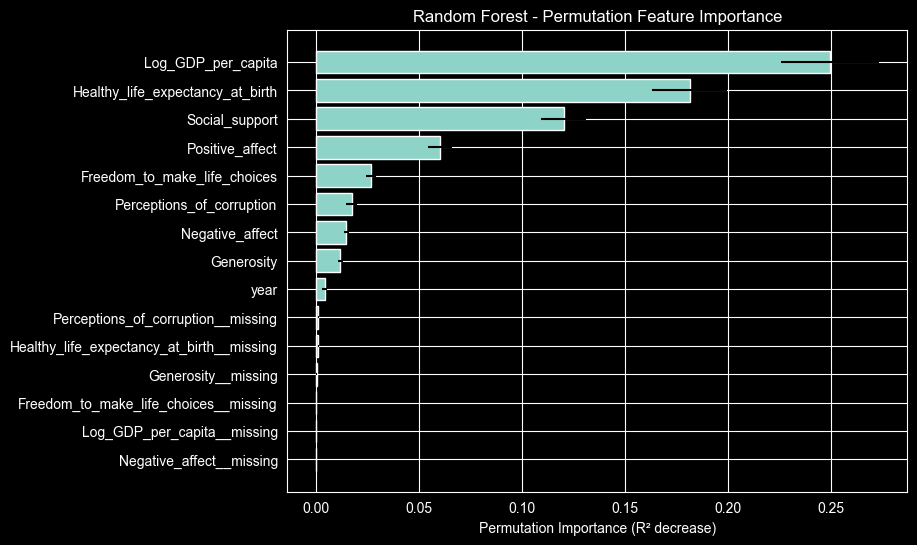

In [37]:
perm_rf_g = permutation_importance(
    rf_g, X_test_g, y_test_g,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_rf_g_df = pd.DataFrame({
    "feature": X_gallup.columns,
    "importance_mean": perm_rf_g.importances_mean,
    "importance_std": perm_rf_g.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_rf_g_df.head(15))

top = perm_rf_g_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("Random Forest - Permutation Feature Importance")
plt.show()

XGBoost Regressor Results
MAE: 0.34419587964767057
RMSE: 0.44150716164328246
R2: 0.8460667673889019


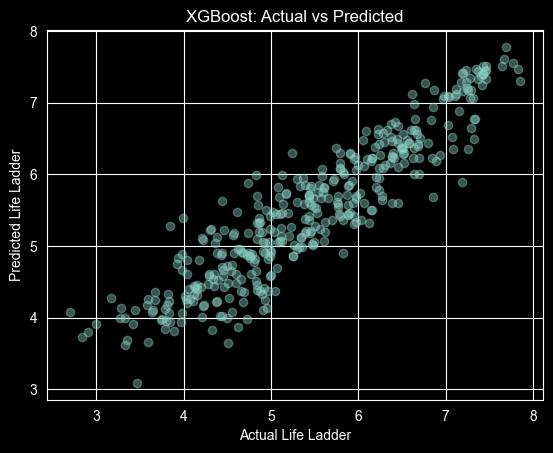

Log_GDP_per_capita                           0.369810
Healthy_life_expectancy_at_birth             0.162164
Positive_affect                              0.095707
Social_support                               0.078892
Healthy_life_expectancy_at_birth__missing    0.054532
Freedom_to_make_life_choices                 0.040792
Perceptions_of_corruption                    0.028591
Log_GDP_per_capita__missing                  0.028525
Negative_affect                              0.026676
Perceptions_of_corruption__missing           0.024175
Generosity                                   0.021352
Generosity__missing                          0.018767
Negative_affect__missing                     0.017594
year                                         0.016671
Freedom_to_make_life_choices__missing        0.008170
dtype: float32


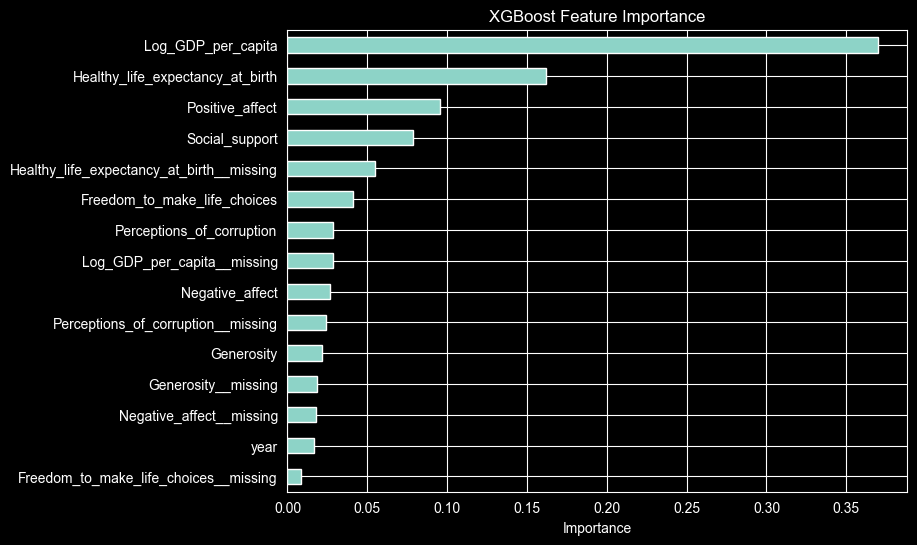

In [38]:
from xgboost import XGBRegressor

xgb_g = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_g.fit(X_train_g, y_train_g)
y_pred_xgb_g = xgb_g.predict(X_test_g)

mae_xgb_g  = mean_absolute_error(y_test_g, y_pred_xgb_g)
rmse_xgb_g = np.sqrt(mean_squared_error(y_test_g, y_pred_xgb_g))
r2_xgb_g   = r2_score(y_test_g, y_pred_xgb_g)

print("XGBoost Regressor Results")
print("MAE:", mae_xgb_g)
print("RMSE:", rmse_xgb_g)
print("R2:", r2_xgb_g)

plt.scatter(y_test_g, y_pred_xgb_g, alpha=0.4)
plt.xlabel("Actual Life Ladder")
plt.ylabel("Predicted Life Ladder")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

xgb_importance_g = pd.Series(
    xgb_g.feature_importances_,
    index=X_gallup.columns
).sort_values(ascending=False)

print(xgb_importance_g.head(15))
xgb_importance_g.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

D:\Diana\Anul III\BachelorArbeit\WellBeingModelling\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


                                      feature  importance_mean  importance_std
1                          Log_GDP_per_capita         0.356920        0.034750
3            Healthy_life_expectancy_at_birth         0.161315        0.017248
2                              Social_support         0.091029        0.010079
7                             Positive_affect         0.059354        0.006350
4                Freedom_to_make_life_choices         0.029635        0.001556
8                             Negative_affect         0.021345        0.003574
5                                  Generosity         0.015027        0.002732
6                   Perceptions_of_corruption         0.014467        0.004010
0                                        year         0.008306        0.002625
11  Healthy_life_expectancy_at_birth__missing         0.006302        0.000589
14         Perceptions_of_corruption__missing         0.001660        0.000628
16                   Negative_affect__missing       

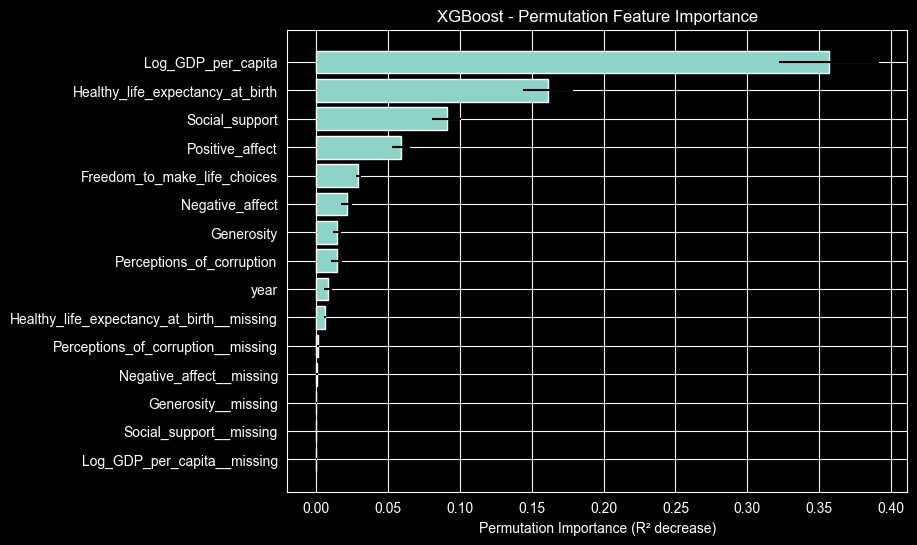

In [39]:
perm_xgb_g = permutation_importance(
    xgb_g, X_test_g, y_test_g,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_xgb_g_df = pd.DataFrame({
    "feature": X_gallup.columns,
    "importance_mean": perm_xgb_g.importances_mean,
    "importance_std": perm_xgb_g.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_xgb_g_df.head(15))

top = perm_xgb_g_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Permutation Importance (R² decrease)")
plt.title("XGBoost - Permutation Feature Importance")
plt.show()

In [40]:
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer

cv_g = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_g = {
    "r2":   "r2",
    "mae":  make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(
        lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
        greater_is_better=False
    )
}

models_g = {
    "Linear Regression": linreg_g,
    "Decision Tree":     tree_g,
    "Random Forest":     rf_g,
    "XGBoost":           xgb_g,
}

cv_results_g = {}
for name, model in models_g.items():
    scores = cross_validate(model, X_gallup, y_gallup,
                            cv=cv_g, scoring=scoring_g, n_jobs=-1)
    cv_results_g[name] = {
        "R² (mean)":   round(scores["test_r2"].mean(), 3),
        "R² (std)":    round(scores["test_r2"].std(), 3),
        "MAE (mean)":  round(-scores["test_mae"].mean(), 3),
        "MAE (std)":   round(scores["test_mae"].std(), 3),
        "RMSE (mean)": round(-scores["test_rmse"].mean(), 3),
        "RMSE (std)":  round(scores["test_rmse"].std(), 3),
    }

cv_df_g = pd.DataFrame(cv_results_g).T
print(cv_df_g)
print(f"\nBaseline RMSE (predict mean): {y_gallup.std():.3f}")

                   R² (mean)  R² (std)  MAE (mean)  MAE (std)  RMSE (mean)  \
Linear Regression      0.763     0.008       0.421      0.014        0.543   
Decision Tree          0.785     0.009       0.399      0.013        0.516   
Random Forest          0.843     0.011       0.341      0.015        0.442   
XGBoost                0.850     0.009       0.332      0.009        0.432   

                   RMSE (std)  
Linear Regression       0.019  
Decision Tree           0.017  
Random Forest           0.021  
XGBoost                 0.019  

Baseline RMSE (predict mean): 1.116


In [41]:
results_g = pd.DataFrame([
    {
        "Model":        "Linear Regression",
        "MAE (test)":   round(mae_lin_g, 3),
        "RMSE (test)":  round(rmse_lin_g, 3),
        "R² (test)":    round(r2_lin_g, 3),
        "CV R²":        cv_df_g.loc["Linear Regression", "R² (mean)"],
        "CV R² std":    cv_df_g.loc["Linear Regression", "R² (std)"],
        "CV MAE":       cv_df_g.loc["Linear Regression", "MAE (mean)"],
        "CV RMSE":      cv_df_g.loc["Linear Regression", "RMSE (mean)"],
    },
    {
        "Model":        "Decision Tree",
        "MAE (test)":   round(mae_tree_g, 3),
        "RMSE (test)":  round(rmse_tree_g, 3),
        "R² (test)":    round(r2_tree_g, 3),
        "CV R²":        cv_df_g.loc["Decision Tree", "R² (mean)"],
        "CV R² std":    cv_df_g.loc["Decision Tree", "R² (std)"],
        "CV MAE":       cv_df_g.loc["Decision Tree", "MAE (mean)"],
        "CV RMSE":      cv_df_g.loc["Decision Tree", "RMSE (mean)"],
    },
    {
        "Model":        "Random Forest",
        "MAE (test)":   round(mae_rf_g, 3),
        "RMSE (test)":  round(rmse_rf_g, 3),
        "R² (test)":    round(r2_rf_g, 3),
        "CV R²":        cv_df_g.loc["Random Forest", "R² (mean)"],
        "CV R² std":    cv_df_g.loc["Random Forest", "R² (std)"],
        "CV MAE":       cv_df_g.loc["Random Forest", "MAE (mean)"],
        "CV RMSE":      cv_df_g.loc["Random Forest", "RMSE (mean)"],
    },
    {
        "Model":        "XGBoost",
        "MAE (test)":   round(mae_xgb_g, 3),
        "RMSE (test)":  round(rmse_xgb_g, 3),
        "R² (test)":    round(r2_xgb_g, 3),
        "CV R²":        cv_df_g.loc["XGBoost", "R² (mean)"],
        "CV R² std":    cv_df_g.loc["XGBoost", "R² (std)"],
        "CV MAE":       cv_df_g.loc["XGBoost", "MAE (mean)"],
        "CV RMSE":      cv_df_g.loc["XGBoost", "RMSE (mean)"],
    },
]).set_index("Model")

print(results_g)

                   MAE (test)  RMSE (test)  R² (test)  CV R²  CV R² std  \
Model                                                                     
Linear Regression       0.430        0.550      0.761  0.763      0.008   
Decision Tree           0.418        0.539      0.771  0.785      0.009   
Random Forest           0.352        0.451      0.839  0.843      0.011   
XGBoost                 0.344        0.442      0.846  0.850      0.009   

                   CV MAE  CV RMSE  
Model                               
Linear Regression   0.421    0.543  
Decision Tree       0.399    0.516  
Random Forest       0.341    0.442  
XGBoost             0.332    0.432  


In [ ]:
## Baseline Models — Results Summary (World Happiness Report Notebooks)


### Section 1: Synthetic Kaggle Dataset

#### Dataset
# - 4,000 rows, 10 countries, 20 years (2005–2024)
# - Target: Life_Satisfaction (continuous, 0–10)
# - Baseline RMSE (predict mean): 1.434

#### Data Quality Finding
# Life_Satisfaction has near-zero correlation with all predictors
# (max |r| = 0.049, mean |r| = 0.017). Correlation with
# Happiness_Score = 0.015. All countries show nearly identical
# means and variances. Target was generated independently of
# predictors — dataset is synthetic by construction.

#### Model Performance
# All models perform at or below baseline (R² ≈ 0):
# - Linear Regression : CV R² = -0.003, CV RMSE = 1.436
# - Random Forest     : CV R² = -0.009, CV RMSE = 1.440
# - XGBoost           : CV R² = -0.065, CV RMSE = 1.479
# - Decision Tree     : CV R² = -0.115, CV RMSE = 1.514
#
# This is a data quality failure, not a modelling failure.
# Retained as a cautionary example in the thesis.
#
# ---

### Section 2: Real WHR Gallup Poll Dataset (2005–2020)

#### Dataset
# - 1,949 country-year observations, 149 countries
# - Target: Life_Ladder (continuous, 0–10 Cantril scale)
# - Baseline RMSE (predict mean): 1.116
# - Genuine empirical signal confirmed: max |r| = 0.783,
#   mean |r| = 0.261

#### Model Performance
# All models perform substantially above baseline:
#
# | Model | CV R² | CV RMSE | CV MAE |
# |---|---|---|---|
# | Linear Regression | 0.763 | 0.543 | 0.421 |
# | Decision Tree | 0.785 | 0.516 | 0.399 |
# | Random Forest | 0.843 | 0.442 | 0.341 |
# | XGBoost | 0.850 | 0.432 | 0.332 |
#
# - XGBoost achieves the best performance (CV R²: 0.850,
#   CV RMSE: 0.432), consistent with findings across all
#   individual-level datasets.
# - Random Forest is close behind (CV R²: 0.843), confirming
#   ensemble methods dominate for tabular wellbeing data.
# - Decision Tree performs competitively (CV R²: 0.785) —
#   notably stronger than on individual-level datasets,
#   suggesting macro-level data has cleaner structure.
# - Linear Regression achieves strong R² (0.763), confirming
#   the relationship between societal indicators and happiness
#   is largely linear, consistent with the high pairwise
#   correlations (GDP: 0.783, life expectancy: 0.741).
# - CV std is low (0.008–0.011), indicating stable
#   generalization across folds.

#### Feature Importance
# Log_GDP_per_capita dominates across all models (permutation
# importance: 0.25–0.36 R² decrease), followed by
# Healthy_life_expectancy and Social_support. This is
# consistent with the WHR literature and validates the
# model's alignment with established findings. Positive_affect
# and Negative_affect show moderate importance (~0.06 and
# ~0.02) — noted as potential proxy predictors from the
# same survey instrument.

#### Key Finding for RQ1 — Micro vs Macro Comparison
# The Gallup dataset produces substantially higher R² than
# all individual-level regression datasets:
#
# | Dataset | Level | Best CV R² |
# |---|---|---|
# | Canadian Survey | Micro | 0.422 |
# | WHR Gallup | Macro | 0.850 |
# | Student Depression | Micro | 0.841 (F1, classification) |
# | MH Tech | Micro | 0.470 (F1, classification) |
#
# The macro-level dataset is more predictable than the
# individual-level Canadian Survey regression task by a
# factor of ~2x in R². This supports the thesis argument
# that societal-level wellbeing indicators have stronger
# and more consistent relationships with aggregate outcomes
# than individual-level psychological predictors do with
# individual outcomes — directly addressing RQ1.

# This result should be interpreted carefully: the WHR
# predictors are themselves composite societal indicators
# (GDP, life expectancy) that are more structurally related
# to the Cantril ladder than individual survey items are to
# self-reported depression or work interference. The higher
# R² reflects both genuine signal and the construct
# alignment between macro predictors and macro outcomes.